# Project 2 — Phase 2: VoG ranking + ResNet50 baseline

Notebook przygotowany pod **Google Colab**.

Celem jest porównanie uczenia modelu na:

1. pełnym zbiorze roboczym,
2. podzbiorze wybranym przez **Variance of Gradients (VoG)** jako najtrudniejsze przykłady,
3. podzbiorze najłatwiejszych przykładów według VoG,
4. losowym podzbiorze o tym samym rozmiarze.

Następnie porównujemy dwa tryby transfer learningu na bazie `torchvision.models.resnet50(weights=ResNet50_Weights.IMAGENET1K_V2)`:

- **Frozen / Linear Probe** — uczymy tylko ostatnią warstwę klasyfikatora,
- **Unfrozen / Fine-tuning** — douczamy cały model.

Źródła metodyczne:

- Agarwal, D'Souza, Hooker, *Estimating Example Difficulty using Variance of Gradients*, CVPR 2022 / arXiv: https://arxiv.org/abs/2008.11600
- Kod autorów VoG: https://github.com/chirag-agarwall/VOG
- Opis projektu: https://github.com/WolodjaZ/Warsztaty-badawcze-2-2026/blob/main/project_description.md

**Uwaga praktyczna:** domyślnie notebook działa w trybie `QUICK_RUN=True`, żeby dało się go odpalić na darmowym Colabie. Żeby uruchomić pełniejszą wersję eksperymentu, ustaw `quick_run=False` w konfiguracji.

## 0. Instalacja zależności

W Colabie PyTorch i TorchVision zwykle są już zainstalowane. Ta komórka doinstalowuje tylko lekkie biblioteki pomocnicze.

In [1]:
!pip -q install -U pandas matplotlib tqdm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 3.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 80.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 70.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.2 which is incompatible.
db-dtypes 1.5.1 requires pandas<3.0.0,>=1.5.3, but you have pandas 3.0.2 which is incompatible.
gradio 5.50.0 requires pandas<3.0,>=1.0, but you have pandas 3.0.2 which is incompatible.
bqplot 0.12.45 requires pandas<3.0.0,>=1.0.0, but you have pandas 3.0.2 which is incompatible.
dask-cudf-cu12 26.2.1 requires pandas<2.4.0,>=2.0, but you have pandas 3.0.2 which is incompatible.
cudf-cu12 26.2.1 requires pandas<2.4

## 1. Importy i konfiguracja

Najważniejsze przełączniki:

- `quick_run=True` — mały, szybki eksperyment testowy,
- `train_pool_size` — ile przykładów z train użyć jako zbiór roboczy,
- `val_pool_size` — ile przykładów z validation użyć do oceny,
- `vog_epochs` — liczba checkpointów/epok użyta do obliczenia VoG,
- `grad_pool_size` — rozdzielczość map gradientów używana przy VoG. W pracy VoG liczy się po pikselach. Tutaj domyślnie kompresujemy gradient do `32x32`, żeby notebook był wykonalny na Colabie. Ustaw `224`, jeśli chcesz wersję bliższą pełnej rozdzielczości, ale będzie dużo wolniej i ciężej pamięciowo.

In [2]:
import os
import random
import time
from dataclasses import dataclass, asdict
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from torchvision import transforms
from torchvision.datasets import ImageFolder
from torchvision.datasets.utils import download_and_extract_archive
from torchvision.models import resnet50, ResNet50_Weights

try:
    from IPython.display import display
except Exception:
    display = print


@dataclass
class Config:
    seed: int = 42
    quick_run: bool = True

    # Zamiast HuggingFace `load_dataset(...)` używamy zwykłego importu z torchvision:
    # ImageFolder + download_and_extract_archive. To jest stabilniejsze w Colabie.
    dataset_source: str = "fastai/imagenette"
    dataset_variant: str = "160"   # opcje: "160", "320", "full"
    data_dir: str = "data"
    num_classes: int = 10

    # QUICK_RUN ogranicza rozmiar, żeby notebook przeszedł na Colabie.
    # Ustaw None przy full run.
    train_pool_size: int | None = 1200
    val_pool_size: int | None = 600

    image_size: int = 224
    batch_size: int = 32
    grad_batch_size: int = 16
    num_workers: int = 2

    # Ranking VoG
    vog_probe_mode: str = "frozen"  # frozen albo unfrozen; frozen jest dużo tańszy
    vog_epochs: int = 3
    grad_pool_size: int = 32

    # Eksperymenty Phase 2
    subset_fraction: float = 0.50
    strategies: tuple[str, ...] = ("full", "hard_vog", "easy_vog", "random")
    model_modes: tuple[str, ...] = ("frozen", "unfrozen")

    frozen_epochs: int = 3
    unfrozen_epochs: int = 2
    lr_frozen: float = 3e-4
    lr_unfrozen: float = 1e-5
    weight_decay: float = 1e-4

    use_amp: bool = True
    output_dir: str = "phase2_vog_outputs"


cfg = Config()

if not cfg.quick_run:
    cfg.train_pool_size = None
    cfg.val_pool_size = None
    cfg.vog_epochs = max(cfg.vog_epochs, 3)

Path(cfg.output_dir).mkdir(parents=True, exist_ok=True)
Path(cfg.data_dir).mkdir(parents=True, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
print(pd.Series(asdict(cfg)))

Device: cuda
seed                                               42
quick_run                                        True
dataset_source                      fastai/imagenette
dataset_variant                                   160
data_dir                                         data
num_classes                                        10
train_pool_size                                  1200
val_pool_size                                     600
image_size                                        224
batch_size                                         32
grad_batch_size                                    16
num_workers                                         2
vog_probe_mode                                 frozen
vog_epochs                                          3
grad_pool_size                                     32
subset_fraction                                   0.5
strategies         (full, hard_vog, easy_vog, random)
model_modes                        (frozen, unfrozen)
frozen_epochs  

## 2. Funkcje pomocnicze

In [3]:
def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = True


def stratified_indices(labels, max_items: int | None, seed: int) -> list[int]:
    """Zwraca indeksy z zachowaniem możliwie równej reprezentacji klas."""
    labels = np.asarray(labels)
    all_indices = np.arange(len(labels))
    if max_items is None or max_items >= len(labels):
        return all_indices.tolist()

    rng = np.random.default_rng(seed)
    classes = np.unique(labels)
    per_class = max(1, max_items // len(classes))
    selected = []

    for cls in classes:
        cls_idx = np.where(labels == cls)[0]
        rng.shuffle(cls_idx)
        selected.extend(cls_idx[: min(per_class, len(cls_idx))].tolist())

    # dopełnienie, jeśli przez zaokrąglenia mamy za mało próbek
    if len(selected) < max_items:
        remaining = np.setdiff1d(all_indices, np.asarray(selected), assume_unique=False)
        rng.shuffle(remaining)
        selected.extend(remaining[: max_items - len(selected)].tolist())

    rng.shuffle(selected)
    return selected[:max_items]


def seed_worker(worker_id: int) -> None:
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

## 3. Dane: Imagenette przez `torchvision.datasets.ImageFolder`

Nie używamy tutaj `datasets.load_dataset(...)`. Notebook pobiera oryginalne archiwum Imagenette i importuje dane jako zwykły folder obrazów przez `ImageFolder`. Dzięki temu kod jest prostszy i mniej podatny na problemy z HuggingFace Datasets w Colabie.

In [4]:
set_seed(cfg.seed)

IMAGENETTE_URLS = {
    "160": ("imagenette2-160", "https://s3.amazonaws.com/fast-ai-imageclas/imagenette2-160.tgz"),
    "320": ("imagenette2-320", "https://s3.amazonaws.com/fast-ai-imageclas/imagenette2-320.tgz"),
    "full": ("imagenette2", "https://s3.amazonaws.com/fast-ai-imageclas/imagenette2.tgz"),
}

IMAGENETTE_WNID_TO_NAME = {
    "n01440764": "tench",
    "n02102040": "English springer",
    "n02979186": "cassette player",
    "n03000684": "chain saw",
    "n03028079": "church",
    "n03394916": "French horn",
    "n03417042": "garbage truck",
    "n03425413": "gas pump",
    "n03445777": "golf ball",
    "n03888257": "parachute",
}


def prepare_imagenette(data_dir: str | Path, variant: str) -> Path:
    if variant not in IMAGENETTE_URLS:
        raise ValueError(f"Nieznany wariant datasetu: {variant}. Dostępne: {list(IMAGENETTE_URLS)}")

    folder_name, url = IMAGENETTE_URLS[variant]
    data_dir = Path(data_dir)
    dataset_root = data_dir / folder_name
    train_dir = dataset_root / "train"
    val_dir = dataset_root / "val"

    if train_dir.exists() and val_dir.exists():
        print("Dataset już istnieje:", dataset_root)
        return dataset_root

    print("Pobieram Imagenette:", url)
    download_and_extract_archive(
        url=url,
        download_root=str(data_dir),
        extract_root=str(data_dir),
        filename=f"{folder_name}.tgz",
    )

    if not train_dir.exists() or not val_dir.exists():
        raise FileNotFoundError(f"Nie znaleziono katalogów train/val po rozpakowaniu: {dataset_root}")

    return dataset_root


dataset_root = prepare_imagenette(cfg.data_dir, cfg.dataset_variant)
train_dir = dataset_root / "train"
val_dir = dataset_root / "val"

# Dataset bez transformacji służy tylko do etykiet, indeksów i podglądu obrazów.
train_base_plain = ImageFolder(str(train_dir))
val_base_plain = ImageFolder(str(val_dir))

class_names = [IMAGENETTE_WNID_TO_NAME.get(wnid, wnid) for wnid in train_base_plain.classes]
cfg.num_classes = len(class_names)

print("Folder datasetu:", dataset_root)
print("Liczba klas:", len(class_names))
print("Klasy:", class_names)
print("Train:", len(train_base_plain), "Validation:", len(val_base_plain))

train_labels_all = [label for _, label in train_base_plain.samples]
val_labels_all = [label for _, label in val_base_plain.samples]

working_train_indices = stratified_indices(train_labels_all, cfg.train_pool_size, cfg.seed)
working_val_indices = stratified_indices(val_labels_all, cfg.val_pool_size, cfg.seed + 1)

print("Roboczy train:", len(working_train_indices))
print("Roboczy validation:", len(working_val_indices))

Pobieram Imagenette: https://s3.amazonaws.com/fast-ai-imageclas/imagenette2-160.tgz


100%|██████████| 99.0M/99.0M [00:02<00:00, 49.1MB/s]


Folder datasetu: data/imagenette2-160
Liczba klas: 10
Klasy: ['tench', 'English springer', 'cassette player', 'chain saw', 'church', 'French horn', 'garbage truck', 'gas pump', 'golf ball', 'parachute']
Train: 9469 Validation: 3925
Roboczy train: 1200
Roboczy validation: 600


## 4. Transformacje i dataset PyTorch

Do oceny i VoG używamy deterministycznego preprocessingu zgodnego z wagami `IMAGENET1K_V2`. Do treningu dokładamy proste augmentacje.

In [5]:
weights = ResNet50_Weights.IMAGENET1K_V2

# Transformacja ewaluacyjna zgodna z wagami TorchVision.
eval_transform = weights.transforms()

# Transformacja treningowa: rozmiar i normalizacja jak ImageNet, plus lekka augmentacja.
train_transform = transforms.Compose([
    transforms.Resize(232),
    transforms.RandomResizedCrop(cfg.image_size, scale=(0.70, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# Osobne obiekty ImageFolder, bo każdy ma własną transformację.
train_dataset_for_training = ImageFolder(str(train_dir), transform=train_transform)
train_dataset_for_eval = ImageFolder(str(train_dir), transform=eval_transform)
val_dataset_for_eval = ImageFolder(str(val_dir), transform=eval_transform)


class IndexedImageFolderSubset(Dataset):
    def __init__(self, base_dataset: ImageFolder, indices: list[int]):
        self.base_dataset = base_dataset
        self.indices = [int(i) for i in indices]

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, pos: int):
        ds_idx = self.indices[pos]
        image, label = self.base_dataset[ds_idx]
        return image, int(label), int(ds_idx)


def make_loader(base_dataset: ImageFolder, indices, batch_size, shuffle=False, drop_last=False):
    dataset = IndexedImageFolderSubset(base_dataset, indices)
    generator = torch.Generator()
    generator.manual_seed(cfg.seed)
    return DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        drop_last=drop_last,
        num_workers=cfg.num_workers,
        pin_memory=torch.cuda.is_available(),
        worker_init_fn=seed_worker,
        generator=generator,
    )

val_loader = make_loader(val_dataset_for_eval, working_val_indices, cfg.batch_size, shuffle=False)

## 5. Model ResNet50: Frozen vs Unfrozen

- `frozen`: zamrażamy backbone i uczymy tylko `model.fc`.
- `unfrozen`: uczymy cały model, czyli klasyczny fine-tuning.

In [6]:
def build_resnet50(num_classes: int, mode: str) -> nn.Module:
    if mode not in {"frozen", "unfrozen"}:
        raise ValueError("mode musi być: 'frozen' albo 'unfrozen'")

    model = resnet50(weights=ResNet50_Weights.IMAGENET1K_V2)
    in_features = model.fc.in_features
    model.fc = nn.Linear(in_features, num_classes)

    if mode == "frozen":
        for p in model.parameters():
            p.requires_grad = False
        for p in model.fc.parameters():
            p.requires_grad = True
    else:
        for p in model.parameters():
            p.requires_grad = True

    return model


def count_trainable_params(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

for mode in cfg.model_modes:
    tmp = build_resnet50(cfg.num_classes, mode)
    print(mode, "trainable params:", f"{count_trainable_params(tmp):,}")
    del tmp

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:01<00:00, 81.7MB/s]


frozen trainable params: 20,490
unfrozen trainable params: 23,528,522


## 6. Implementacja VoG

Dla każdego obrazu liczymy gradient wybranego logitu względem wejścia:

\[
S_t(x) = \frac{\partial z_y(x; \theta_t)}{\partial x}
\]

czyli gradient logitu prawdziwej klasy `y` po pikselach obrazu, dla kilku checkpointów modelu `t = 1, ..., K`.

Następnie liczymy odchylenie gradientów w czasie treningu:

\[
\mathrm{VoG}(x) = \frac{1}{N}\sum_{i=1}^{N}\sqrt{\frac{1}{K}\sum_{t=1}^{K}\left(S_t(x)_i - \mu_i(x)\right)^2}
\]

Na końcu normalizujemy wynik wewnątrz każdej klasy, bo różne klasy mogą naturalnie mieć różne skale gradientów.

In [7]:
def collect_input_gradients(model: nn.Module, loader: DataLoader, device: torch.device, grad_pool_size: int) -> tuple[dict[int, torch.Tensor], dict[int, int]]:
    """Zbiera mapy gradientów wejścia dla wszystkich próbek z loadera.

    Zwraca:
    - gradients_by_id: {oryginalny indeks w ImageFolder -> tensor [grad_pool_size, grad_pool_size] na CPU}
    - labels_by_id: {oryginalny indeks w ImageFolder -> etykieta}
    """
    model.eval()
    gradients_by_id: dict[int, torch.Tensor] = {}
    labels_by_id: dict[int, int] = {}

    for x, y, idx in tqdm(loader, desc="input gradients", leave=False):
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)
        idx = idx.cpu().numpy().tolist()

        x.requires_grad_(True)
        model.zero_grad(set_to_none=True)

        logits = model(x)
        selected_logits = logits.gather(1, y.view(-1, 1)).sum()
        selected_logits.backward()

        grad = x.grad.detach().float().cpu()      # [B, 3, 224, 224]
        grad = grad.mean(dim=1, keepdim=True)     # średnia po kanałach RGB, zgodnie z ideą VoG

        if grad_pool_size != grad.shape[-1]:
            grad = F.adaptive_avg_pool2d(grad, output_size=(grad_pool_size, grad_pool_size))

        grad = grad.squeeze(1).contiguous()       # [B, H, W]

        for local_i, ds_idx in enumerate(idx):
            gradients_by_id[int(ds_idx)] = grad[local_i]
            labels_by_id[int(ds_idx)] = int(y[local_i].item())

        del x, y, logits, selected_logits, grad
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    return gradients_by_id, labels_by_id


def compute_vog_dataframe(snapshots: list[dict[int, torch.Tensor]], labels_by_id: dict[int, int]) -> pd.DataFrame:
    """Liczy raw VoG i klasowo znormalizowany VoG z listy checkpointów gradientów."""
    common_ids = set(snapshots[0].keys())
    for snap in snapshots[1:]:
        common_ids &= set(snap.keys())
    common_ids = sorted(common_ids)

    rows = []
    for ds_idx in tqdm(common_ids, desc="VoG scores"):
        stack = torch.stack([snap[ds_idx] for snap in snapshots], dim=0).float()  # [K, H, W]
        mu = stack.mean(dim=0, keepdim=True)
        vog = torch.sqrt(((stack - mu) ** 2).mean(dim=0)).mean().item()
        rows.append({"idx": int(ds_idx), "label": int(labels_by_id[ds_idx]), "vog_raw": float(vog)})

    df = pd.DataFrame(rows)
    df["class_name"] = df["label"].map(lambda i: class_names[int(i)])

    eps = 1e-12
    df["vog_z"] = df.groupby("label")["vog_raw"].transform(
        lambda s: (s - s.mean()) / (s.std(ddof=0) + eps)
    )
    df["rank_hard"] = df["vog_z"].rank(ascending=False, method="first").astype(int)
    df["rank_easy"] = df["vog_z"].rank(ascending=True, method="first").astype(int)
    return df.sort_values("vog_z", ascending=False).reset_index(drop=True)

## 7. Trening krótkiego modelu-probe i obliczenie rankingu VoG

W artykule VoG jest liczony z gradientów z kilku checkpointów treningu. Tutaj trenujemy krótki model-probe przez `vog_epochs` epok i po każdej epoce zapisujemy gradienty wejścia.

Domyślnie probe jest `frozen`, bo ranking ma być tani. Możesz ustawić `cfg.vog_probe_mode = "unfrozen"`, ale czas i zużycie VRAM wzrosną.

In [8]:
def train_one_epoch(model, loader, optimizer, criterion, device, use_amp=True):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    amp_enabled = bool(use_amp and device.type == "cuda")
    scaler = torch.cuda.amp.GradScaler(enabled=amp_enabled)

    for x, y, _ in tqdm(loader, desc="train", leave=False):
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        with torch.cuda.amp.autocast(enabled=amp_enabled):
            logits = model(x)
            loss = criterion(logits, y)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item() * x.size(0)
        correct += (logits.argmax(dim=1) == y).sum().item()
        total += x.size(0)

    return {"loss": running_loss / total, "acc": correct / total}


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    for x, y, _ in tqdm(loader, desc="eval", leave=False):
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)
        logits = model(x)
        loss = criterion(logits, y)

        running_loss += loss.item() * x.size(0)
        correct += (logits.argmax(dim=1) == y).sum().item()
        total += x.size(0)

    return {"loss": running_loss / total, "acc": correct / total}


def optimizer_for(model, mode: str):
    params = [p for p in model.parameters() if p.requires_grad]
    lr = cfg.lr_frozen if mode == "frozen" else cfg.lr_unfrozen
    return torch.optim.AdamW(params, lr=lr, weight_decay=cfg.weight_decay)

In [9]:
set_seed(cfg.seed)

ranking_train_loader = make_loader(
    train_dataset_for_training,
    working_train_indices,
    batch_size=cfg.batch_size,
    shuffle=True,
)

ranking_grad_loader = make_loader(
    train_dataset_for_eval,
    working_train_indices,
    batch_size=cfg.grad_batch_size,
    shuffle=False,
)

criterion = nn.CrossEntropyLoss()
probe_model = build_resnet50(cfg.num_classes, cfg.vog_probe_mode).to(device)
probe_optimizer = optimizer_for(probe_model, cfg.vog_probe_mode)

gradient_snapshots = []
labels_by_id_global = {}
probe_history = []

start = time.time()
for epoch in range(1, cfg.vog_epochs + 1):
    print(f"\nVoG probe epoch {epoch}/{cfg.vog_epochs}")
    train_metrics = train_one_epoch(probe_model, ranking_train_loader, probe_optimizer, criterion, device, cfg.use_amp)
    val_metrics = evaluate(probe_model, val_loader, criterion, device)
    row = {"epoch": epoch, **{f"train_{k}": v for k, v in train_metrics.items()}, **{f"val_{k}": v for k, v in val_metrics.items()}}
    probe_history.append(row)
    print(row)

    grads, labels = collect_input_gradients(probe_model, ranking_grad_loader, device, cfg.grad_pool_size)
    gradient_snapshots.append(grads)
    labels_by_id_global.update(labels)

print(f"\nRanking stage time: {(time.time() - start)/60:.1f} min")

probe_history_df = pd.DataFrame(probe_history)
display(probe_history_df)

vog_df = compute_vog_dataframe(gradient_snapshots, labels_by_id_global)
vog_path = Path(cfg.output_dir) / "vog_scores.csv"
vog_df.to_csv(vog_path, index=False)
print("Zapisano:", vog_path)
display(vog_df.head(10))


VoG probe epoch 1/3


/tmp/ipykernel_12533/2023114545.py:7: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=amp_enabled)


train:   0%|          | 0/38 [00:00<?, ?it/s]

/tmp/ipykernel_12533/2023114545.py:14: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=amp_enabled):


eval:   0%|          | 0/19 [00:00<?, ?it/s]

...


Ranking stage time: 1.2 min


,epoch,train_loss,train_acc,val_loss,val_acc
0,1,1.900053,0.668333,1.568735,0.925000
1,2,1.273886,0.926667,1.069128,0.960000
2,3,0.889813,0.955833,0.793804,0.968333


VoG scores:   0%|          | 0/1200 [00:00<?, ?it/s]

Zapisano: phase2_vog_outputs/vog_scores.csv


,idx,label,vog_raw,class_name,vog_z,rank_hard,rank_easy
0,6945,7,0.001333,gas pump,7.107373,1,1200
1,276,0,0.002064,tench,6.236860,2,1199
2,4906,5,0.001596,French horn,5.460519,3,1198
3,5740,6,0.001342,garbage truck,5.158370,4,1197
4,9205,9,0.002409,parachute,4.713369,5,1196
5,3565,3,0.001014,chain saw,4.563802,6,1195
6,2793,2,0.001395,cassette player,4.553836,7,1194
7,1576,1,0.001414,English springer,4.381451,8,1193
8,7237,7,0.000888,gas pump,4.245732,9,1192
9,319,0,0.001468,tench,4.139542,10,1191


## 8. Wizualizacja rankingu VoG

Wysokie `vog_z` interpretujemy jako przykłady trudniejsze dla modelu: ich gradienty wejścia mocniej zmieniały się między checkpointami.

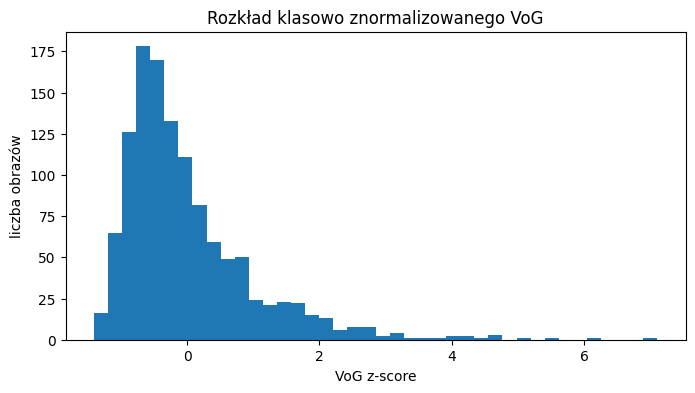

<Figure size 1000x500 with 0 Axes>

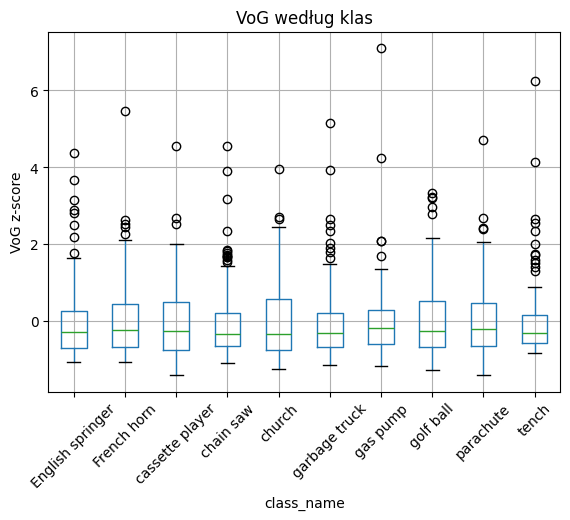

In [10]:
plt.figure(figsize=(8, 4))
plt.hist(vog_df["vog_z"], bins=40)
plt.title("Rozkład klasowo znormalizowanego VoG")
plt.xlabel("VoG z-score")
plt.ylabel("liczba obrazów")
plt.show()

plt.figure(figsize=(10, 5))
vog_df.boxplot(column="vog_z", by="class_name", rot=45)
plt.title("VoG według klas")
plt.suptitle("")
plt.ylabel("VoG z-score")
plt.show()

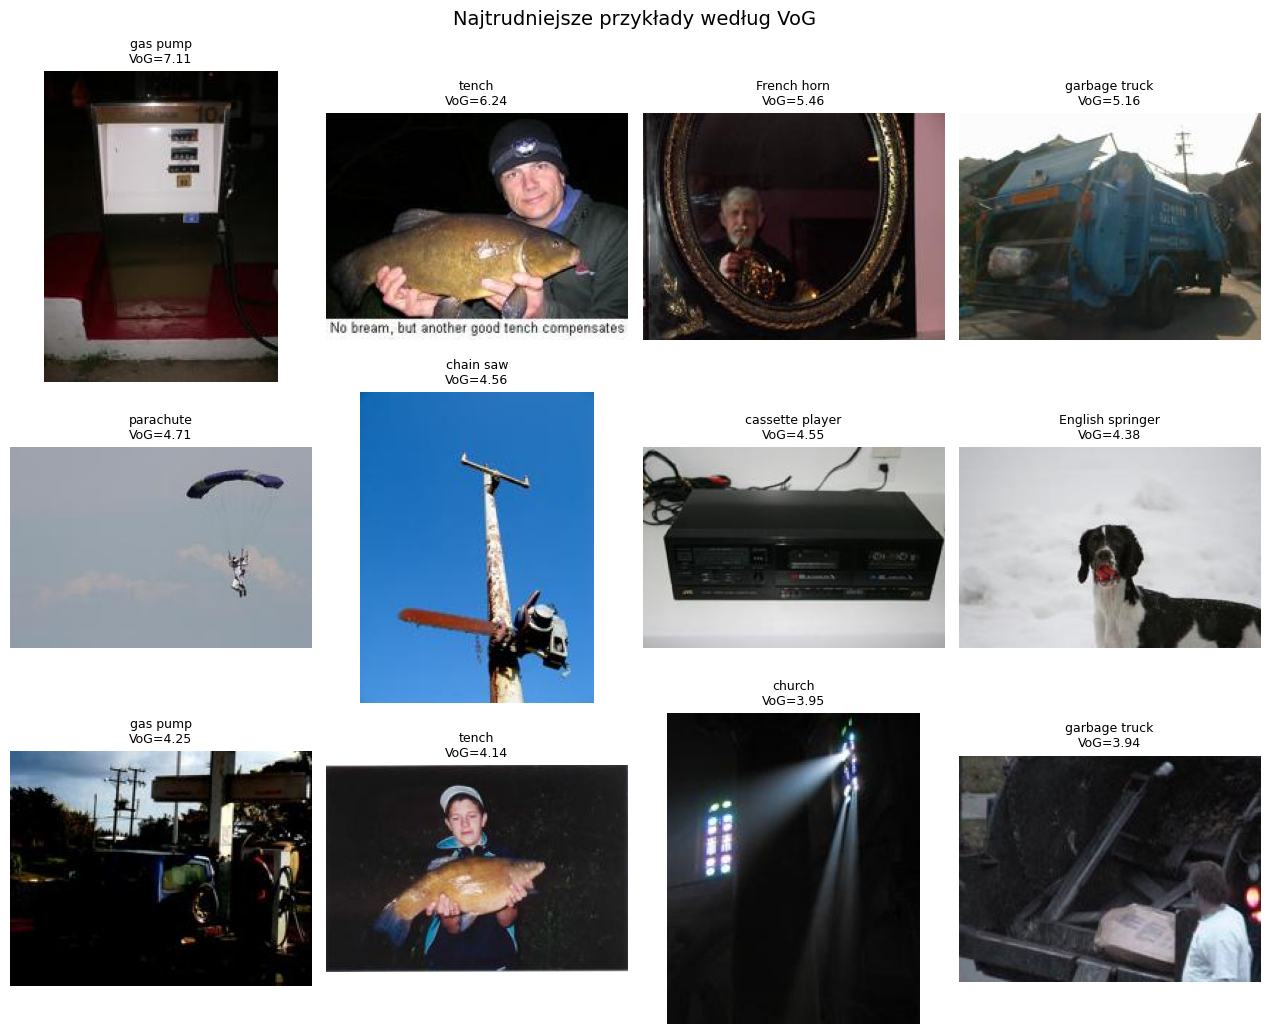

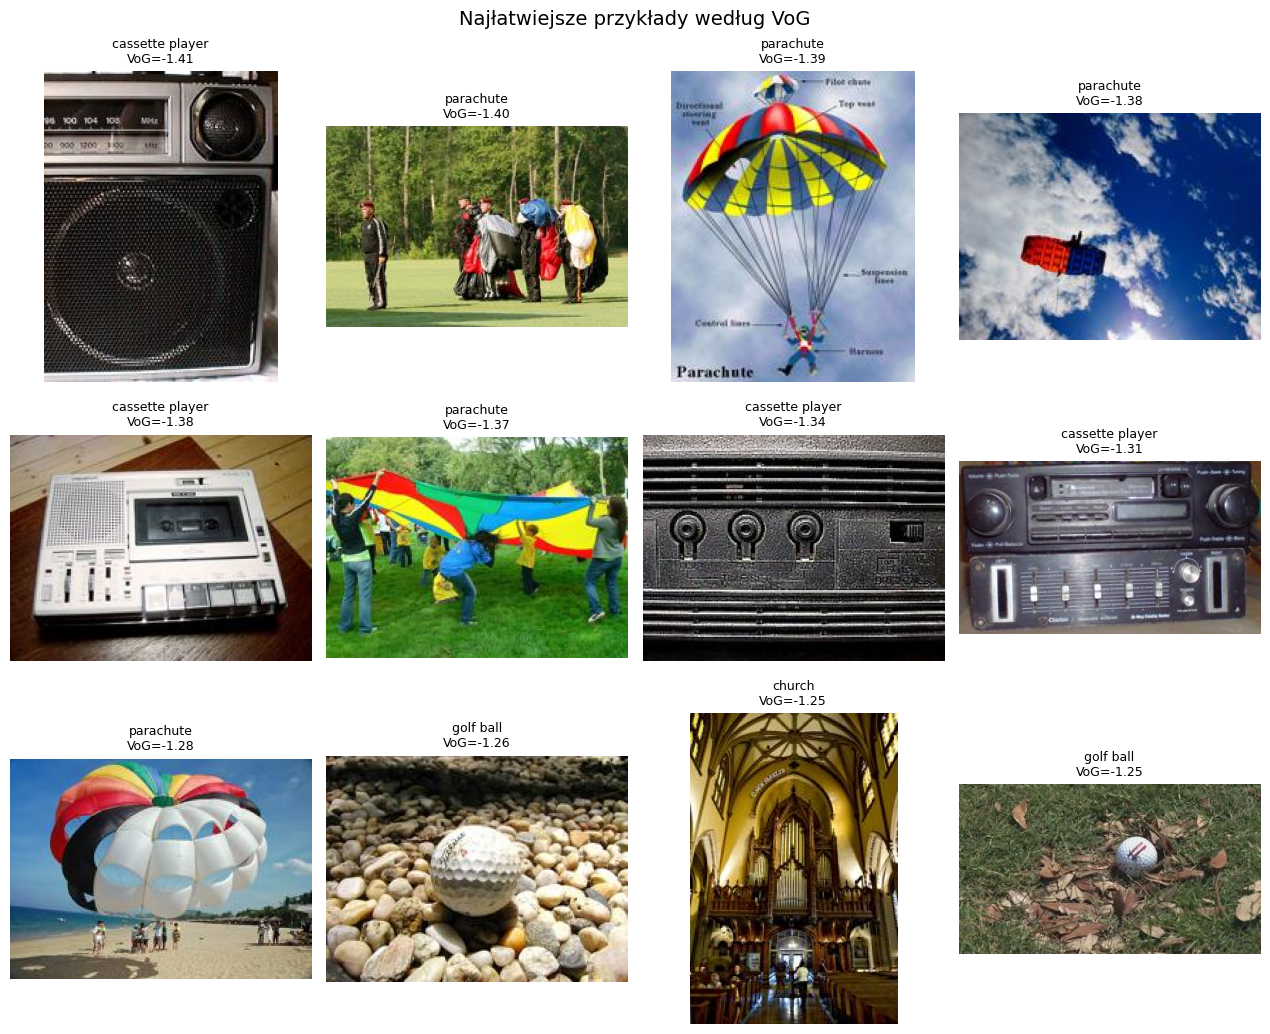

In [11]:
def show_ranked_examples(base_dataset_plain: ImageFolder, df: pd.DataFrame, title: str, highest: bool = True, n: int = 12):
    sample = df.sort_values("vog_z", ascending=not highest).head(n)
    cols = 4
    rows = int(np.ceil(n / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 3.2, rows * 3.5))
    axes = np.array(axes).reshape(-1)

    for ax, (_, row) in zip(axes, sample.iterrows()):
        image_path, _ = base_dataset_plain.samples[int(row["idx"])]
        image = Image.open(image_path).convert("RGB")
        ax.imshow(image)
        ax.axis("off")
        ax.set_title(f"{row['class_name']}\nVoG={row['vog_z']:.2f}", fontsize=9)

    for ax in axes[len(sample):]:
        ax.axis("off")

    fig.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()

show_ranked_examples(train_base_plain, vog_df, "Najtrudniejsze przykłady według VoG", highest=True, n=12)
show_ranked_examples(train_base_plain, vog_df, "Najłatwiejsze przykłady według VoG", highest=False, n=12)

## 9. Budowa podzbiorów: full / hard VoG / easy VoG / random

Selekcję robimy **stratyfikacyjnie w obrębie klas**, żeby ranking nie zmienił proporcji klas.

In [12]:
def select_by_strategy(vog_df: pd.DataFrame, strategy: str, fraction: float, seed: int) -> list[int]:
    if strategy == "full":
        return sorted(vog_df["idx"].astype(int).tolist())

    rng = np.random.default_rng(seed)
    selected = []

    for label, group in vog_df.groupby("label"):
        n = max(1, int(round(len(group) * fraction)))

        if strategy == "hard_vog":
            chosen = group.sort_values("vog_z", ascending=False).head(n)
        elif strategy == "easy_vog":
            chosen = group.sort_values("vog_z", ascending=True).head(n)
        elif strategy == "random":
            chosen = group.sample(n=n, random_state=int(rng.integers(0, 1_000_000)))
        else:
            raise ValueError(f"Nieznana strategia: {strategy}")

        selected.extend(chosen["idx"].astype(int).tolist())

    rng.shuffle(selected)
    return selected


subset_indices = {
    strategy: select_by_strategy(vog_df, strategy, cfg.subset_fraction, cfg.seed + 123)
    for strategy in cfg.strategies
}

summary_rows = []
for strategy, indices in subset_indices.items():
    labels = [int(train_labels_all[i]) for i in indices]
    summary_rows.append({
        "strategy": strategy,
        "n": len(indices),
        "fraction_of_working_train": len(indices) / len(vog_df),
        "class_counts": dict(pd.Series(labels).value_counts().sort_index()),
    })

subset_summary = pd.DataFrame(summary_rows)
display(subset_summary)

,strategy,n,fraction_of_working_train,class_counts
0,full,1200,1.0,"{0: 120, 1: 120, 2: 120, 3: 120, 4: 120, 5: 12..."
1,hard_vog,600,0.5,"{0: 60, 1: 60, 2: 60, 3: 60, 4: 60, 5: 60, 6: ..."
2,easy_vog,600,0.5,"{0: 60, 1: 60, 2: 60, 3: 60, 4: 60, 5: 60, 6: ..."
3,random,600,0.5,"{0: 60, 1: 60, 2: 60, 3: 60, 4: 60, 5: 60, 6: ..."


## 10. Phase 2: eksperymenty treningowe

Dla każdej strategii selekcji trenujemy dwa modele:

- `frozen` — linear probe,
- `unfrozen` — fine-tuning.

Wyniki porównujemy na tym samym zbiorze walidacyjnym.

In [13]:
def run_training_experiment(strategy: str, model_mode: str, train_indices: list[int]) -> tuple[pd.DataFrame, dict]:
    set_seed(cfg.seed)
    model = build_resnet50(cfg.num_classes, model_mode).to(device)
    optimizer = optimizer_for(model, model_mode)
    criterion = nn.CrossEntropyLoss()

    epochs = cfg.frozen_epochs if model_mode == "frozen" else cfg.unfrozen_epochs
    train_loader = make_loader(
        train_dataset_for_training,
        train_indices,
        batch_size=cfg.batch_size,
        shuffle=True,
    )

    rows = []
    best_state = None
    best_val_acc = -1.0

    print(f"\n=== strategy={strategy} | mode={model_mode} | n={len(train_indices)} | epochs={epochs} ===")
    for epoch in range(1, epochs + 1):
        train_metrics = train_one_epoch(model, train_loader, optimizer, criterion, device, cfg.use_amp)
        val_metrics = evaluate(model, val_loader, criterion, device)

        row = {
            "strategy": strategy,
            "model_mode": model_mode,
            "epoch": epoch,
            "n_train": len(train_indices),
            "train_loss": train_metrics["loss"],
            "train_acc": train_metrics["acc"],
            "val_loss": val_metrics["loss"],
            "val_acc": val_metrics["acc"],
        }
        rows.append(row)
        print(row)

        if val_metrics["acc"] > best_val_acc:
            best_val_acc = val_metrics["acc"]
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    hist_df = pd.DataFrame(rows)
    best = hist_df.sort_values("val_acc", ascending=False).iloc[0].to_dict()

    # Sprzątanie VRAM między eksperymentami.
    del model, optimizer, criterion, train_loader
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return hist_df, {"best_state": best_state, "best_row": best}

In [14]:
all_histories = []
best_rows = []

start = time.time()
for model_mode in cfg.model_modes:
    for strategy in cfg.strategies:
        hist_df, best_info = run_training_experiment(strategy, model_mode, subset_indices[strategy])
        all_histories.append(hist_df)
        best_rows.append(best_info["best_row"])

print(f"\nExperiment stage time: {(time.time() - start)/60:.1f} min")

history_df = pd.concat(all_histories, ignore_index=True)
results_df = pd.DataFrame(best_rows).sort_values(["model_mode", "val_acc"], ascending=[True, False])

history_path = Path(cfg.output_dir) / "phase2_training_history.csv"
results_path = Path(cfg.output_dir) / "phase2_best_results.csv"
history_df.to_csv(history_path, index=False)
results_df.to_csv(results_path, index=False)

print("Zapisano:", history_path)
print("Zapisano:", results_path)

display(results_df)


=== strategy=full | mode=frozen | n=1200 | epochs=3 ===


/tmp/ipykernel_12533/2023114545.py:7: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=amp_enabled)


train:   0%|          | 0/38 [00:00<?, ?it/s]

/tmp/ipykernel_12533/2023114545.py:14: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=amp_enabled):


eval:   0%|          | 0/19 [00:00<?, ?it/s]

...

{'strategy': 'random', 'model_mode': 'unfrozen', 'epoch': 1, 'n_train': 600, 'train_loss': 2.2506331380208335, 'train_acc': 0.19833333333333333, 'val_loss': 2.2182305749257405, 'val_acc': 0.25166666666666665}


train:   0%|          | 0/19 [00:00<?, ?it/s]

eval:   0%|          | 0/19 [00:00<?, ?it/s]

{'strategy': 'random', 'model_mode': 'unfrozen', 'epoch': 2, 'n_train': 600, 'train_loss': 2.173172203699748, 'train_acc': 0.31, 'val_loss': 2.148202339808146, 'val_acc': 0.40166666666666667}

Experiment stage time: 7.1 min
Zapisano: phase2_vog_outputs/phase2_training_history.csv
Zapisano: phase2_vog_outputs/phase2_best_results.csv


,strategy,model_mode,epoch,n_train,train_loss,train_acc,val_loss,val_acc
0,full,frozen,3,1200,0.886523,0.961667,0.805561,0.963333
3,random,frozen,3,600,1.389185,0.943333,1.314850,0.951667
1,hard_vog,frozen,3,600,1.425601,0.941667,1.350415,0.948333
2,easy_vog,frozen,3,600,1.359983,0.941667,1.322933,0.923333
4,full,unfrozen,2,1200,2.058549,0.533333,1.982847,0.683333
7,random,unfrozen,2,600,2.173172,0.310000,2.148202,0.401667
5,hard_vog,unfrozen,2,600,2.184736,0.336667,2.154938,0.398333
6,easy_vog,unfrozen,2,600,2.170298,0.321667,2.149823,0.381667


## 11. Wykresy porównawcze

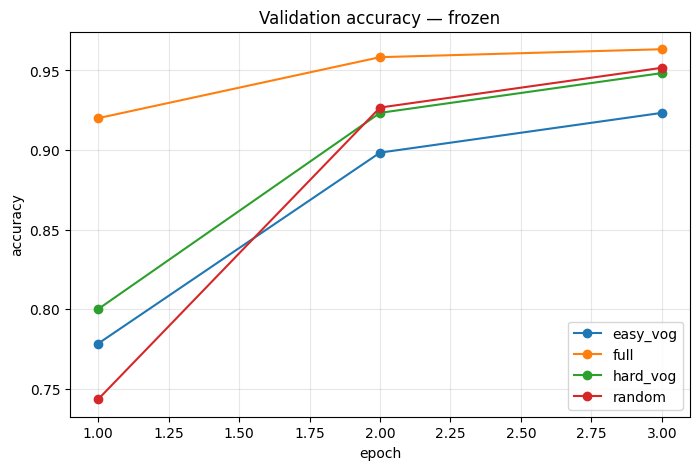

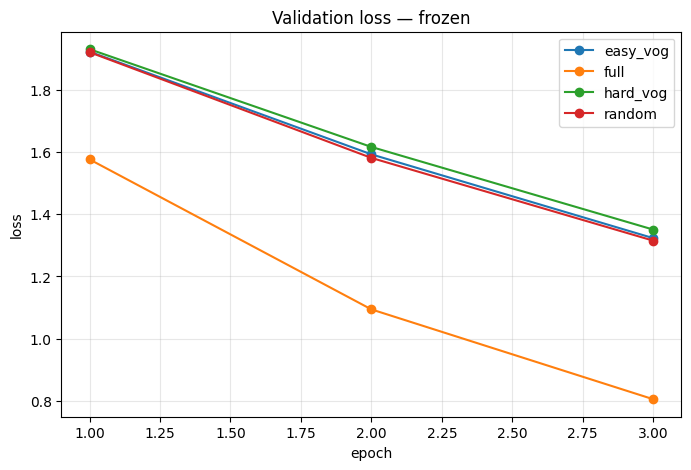

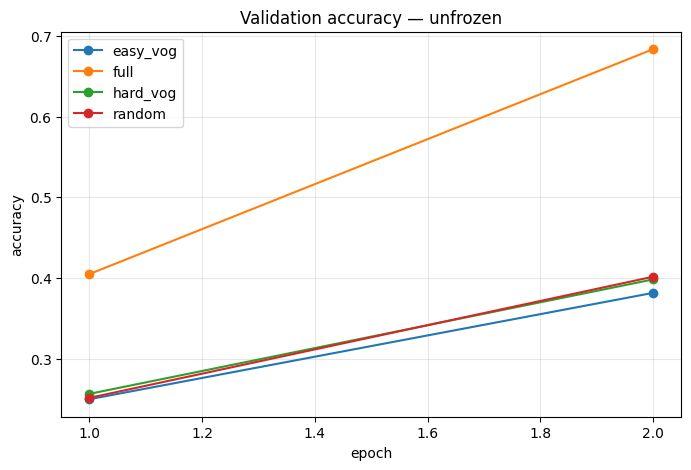

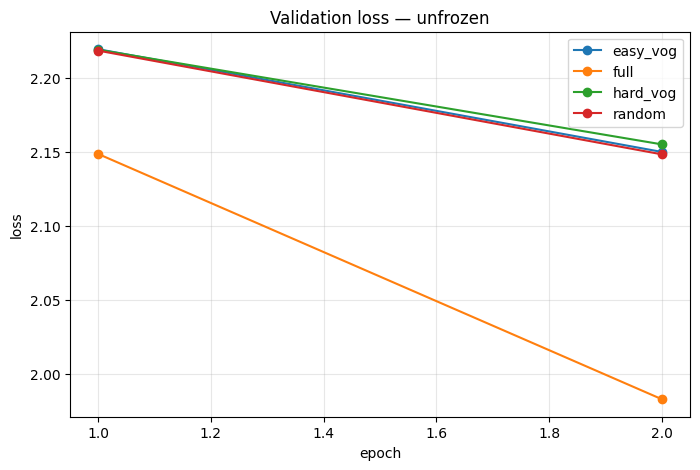

In [15]:
for model_mode in cfg.model_modes:
    tmp = history_df[history_df["model_mode"] == model_mode]

    plt.figure(figsize=(8, 5))
    for strategy, group in tmp.groupby("strategy"):
        group = group.sort_values("epoch")
        plt.plot(group["epoch"], group["val_acc"], marker="o", label=strategy)
    plt.title(f"Validation accuracy — {model_mode}")
    plt.xlabel("epoch")
    plt.ylabel("accuracy")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    plt.figure(figsize=(8, 5))
    for strategy, group in tmp.groupby("strategy"):
        group = group.sort_values("epoch")
        plt.plot(group["epoch"], group["val_loss"], marker="o", label=strategy)
    plt.title(f"Validation loss — {model_mode}")
    plt.xlabel("epoch")
    plt.ylabel("loss")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

## 12. Interpretacja wyników

Po uruchomieniu notebooka uzupełnij poniższe punkty w raporcie:

1. Czy `hard_vog` osiąga lepszą jakość niż `random` przy tym samym rozmiarze podzbioru?
2. Czy `easy_vog` uczy się szybciej na początku, ale gorzej generalizuje?
3. Czy ranking VoG jest bardziej przydatny dla linear probe czy fine-tuningu?
4. Czy pełny zbiór nadal wygrywa jakością końcową, a jeśli tak, to czy podzbiór VoG daje sensowny kompromis koszt/jakość?
5. Czy przykłady o wysokim VoG faktycznie wyglądają na trudniejsze: nietypowy kadr, tło, rozmycie, częściowa zasłona obiektu?

Minimalna tabela do raportu to `results_df`, a wykresy z sekcji 11 pokazują dynamikę treningu.

In [16]:
# Tabela wygodna do raportu
report_table = results_df[[
    "model_mode", "strategy", "n_train", "epoch", "train_acc", "val_acc", "train_loss", "val_loss"
]].copy()

for col in ["train_acc", "val_acc", "train_loss", "val_loss"]:
    report_table[col] = report_table[col].astype(float).round(4)

display(report_table)

,model_mode,strategy,n_train,epoch,train_acc,val_acc,train_loss,val_loss
0,frozen,full,1200,3,0.9617,0.9633,0.8865,0.8056
3,frozen,random,600,3,0.9433,0.9517,1.3892,1.3149
1,frozen,hard_vog,600,3,0.9417,0.9483,1.4256,1.3504
2,frozen,easy_vog,600,3,0.9417,0.9233,1.3600,1.3229
4,unfrozen,full,1200,2,0.5333,0.6833,2.0585,1.9828
7,unfrozen,random,600,2,0.3100,0.4017,2.1732,2.1482
5,unfrozen,hard_vog,600,2,0.3367,0.3983,2.1847,2.1549
6,unfrozen,easy_vog,600,2,0.3217,0.3817,2.1703,2.1498


## 13. Eksport artefaktów

Po zakończeniu notebooka najważniejsze pliki znajdziesz w katalogu `phase2_vog_outputs`:

- `vog_scores.csv` — ranking obrazów,
- `phase2_training_history.csv` — pełna historia treningu,
- `phase2_best_results.csv` — najlepszy wynik dla każdej konfiguracji.

In [17]:
print("Pliki wynikowe:")
for p in sorted(Path(cfg.output_dir).glob("*")):
    print("-", p)

Pliki wynikowe:
- phase2_vog_outputs/phase2_best_results.csv
- phase2_vog_outputs/phase2_training_history.csv
- phase2_vog_outputs/vog_scores.csv
